# EDA quickstart — papers_combined.parquet

**Start here if this is your first time in the repo.** `data/processed/papers_combined.parquet`
is the single, cleaned, model-ready dataset for this project: one row per paper,
pooling all 6 use cases together. It's built by
`notebooks/data_compile/combine_use_cases.ipynb` from the raw JSONL exports +
`usecase.json` search-brief files in `data/raw/` — see that notebook if you want to
know exactly how a column was produced.

A few columns worth knowing before you start:

- **`paper_id`** — the unique key for a row. Use this, not `source_id` (the original
  per-file id), which repeats across use cases.
- **`use_case_key`** / **`use_case_name`** — which of the 6 use cases a row belongs to.
- **`triage_label`** — the analyst's positive/negative/pass judgement. A **null** here
  means "never triaged" — a different fact from `'pass'`, not the same thing.
- **`embedding`** — the precomputed 384-dimension sentence vector for the paper's
  title+abstract, ready to use as model features.
- Everything else is either paper metadata (title, abstract, year, venue, citation
  count, ...) or the matching use case's search-brief fields (`objective`,
  `terms_must_include`, `trl_min`/`trl_max`, ...) broadcast onto every row.

This notebook is a **quickstart** — basic shape, dtypes, missing values, and a
handful of simple charts, deliberately kept plain. For a deeper dive (schema
comparisons, null-rate heatmaps, duplicate checks, use case definitions vs. their
corpora) see the other notebooks in `notebooks/eda/`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "../../data/processed/papers_combined.parquet"

df = pd.read_parquet(DATA_PATH)
print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns from {DATA_PATH}")

Loaded 2873 rows, 50 columns from ../../data/processed/papers_combined.parquet


## 1. Shape and columns

The basics: how big is this, and what's in it.

In [2]:
df.head()

,paper_id,use_case_key,use_case_name,source_id,title,authors,year,venue,doi,url,...,notes,from_arxiv,from_core,from_crossref,from_europe_pmc,from_openalex,from_pubmed,from_seed,from_semantic_scholar,has_abstract
0,carbon_capture__3355,carbon_capture,Carbon Capture,3355,Optimization of amine-based carbon capture: Si...,"Amin Hedayati Moghaddam, Morteza Esfandyari, H...",2024,results in engineering,10.1016/j.rineng.2024.103574,https://doi.org/10.1016/j.rineng.2024.103574,...,,False,False,True,False,False,False,False,False,True
1,carbon_capture__1143,carbon_capture,Carbon Capture,1143,Solvent-mediated modification of thermodynamic...,"N. D. Afify, M. B. Sweatman",2024,the journal of chemical physics,10.1063/5.0169382,https://doi.org/10.1063/5.0169382,...,,False,False,True,False,False,False,False,False,True
2,carbon_capture__1588,carbon_capture,Carbon Capture,1588,Electrifying amine carbon capture with robust ...,"Li X, Musgrave CB, Liu A, Meng J, Zhang J, God...",2025,,10.1038/s41467-025-59732-z,https://doi.org/10.1038/s41467-025-59732-z,...,,False,False,False,True,False,False,False,False,True
3,carbon_capture__1621,carbon_capture,Carbon Capture,1621,Impact of thermodynamics and kinetics on the c...,"Kopac T, Demirel Y.",2024,,10.1007/s11356-024-33792-y,https://doi.org/10.1007/s11356-024-33792-y,...,,False,False,False,True,False,False,False,False,True
4,carbon_capture__3493,carbon_capture,Carbon Capture,3493,Acid-treated activated carbon as simple and in...,"Ali Hassan Bhatti, Mamoona Waris, Wajahat Wahe...",2023,carbon capture science & technology,10.1016/j.ccst.2023.100131,https://ars.els-cdn.com/content/image/1-s2.0-S...,...,,False,False,False,False,True,False,False,False,True


In [3]:
df.dtypes

paper_id                        str
use_case_key                    str
use_case_name                   str
source_id                     int64
title                           str
authors                         str
year                          Int64
venue                           str
doi                             str
url                             str
sources                         str
language                        str
citation_count                Int64
triage_label               category
review_label               category
relevance_score             float64
abstract                        str
embedding                    object
embed_model                     str
embed_dim                     int64
exported_at                     str
app_version                     str
problem_statement               str
objective                       str
usecase_schema_version          str
domain_industry                 str
domain_application              str
domain_technology_focus     

## 2. Missing values

A quick per-column count — not every column is supposed to be full (e.g. `doi` and
`venue` are sometimes genuinely missing from the source). See
`explore_use_cases.ipynb` for a deeper look at what these nulls mean and whether
they're safe to fill.

In [4]:
missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False)

review_label      2872
trl_min           1215
trl_max           1215
triage_label       478
citation_count     410
doi                176
venue               49
authors             26
year                15
url                 14
dtype: int64

## 3. Basic descriptive stats — numeric columns

Plain `.describe()` — count, mean, std, min/max, quartiles.

In [5]:
df[["year", "citation_count", "relevance_score", "trl_min", "trl_max"]].describe()

,year,citation_count,relevance_score,trl_min,trl_max
count,2858.0,2463.0,2873.000000,1658.0,1658.0
mean,2023.481106,82.128705,0.568501,3.146562,6.91918
std,2.937065,578.97151,0.143631,2.140703,2.465351
min,1974.0,0.0,-0.102457,1.0,4.0
25%,2022.0,0.0,0.496222,1.0,4.0
50%,2025.0,2.0,0.584480,3.0,9.0
75%,2025.0,41.0,0.658312,6.0,9.0
max,2027.0,26506.0,0.848641,6.0,9.0


## 4. Basic value counts — key categorical columns

In [6]:
df["use_case_key"].value_counts()

use_case_key
cement_binders      690
soil_microbiome     602
ner                 541
solar_leo           427
carbon_capture      323
tech_forecasting    290
Name: count, dtype: int64

In [7]:
df["triage_label"].value_counts(dropna=False)

triage_label
positive    1067
negative     785
pass         543
NaN          478
Name: count, dtype: int64

In [8]:
df["language"].value_counts().head(10)

language
en    2843
sv       9
fr       4
de       3
it       3
no       3
id       2
es       1
ru       1
da       1
Name: count, dtype: int64

## 5. A handful of simple charts

Nothing fancy — default matplotlib, one chart per question.

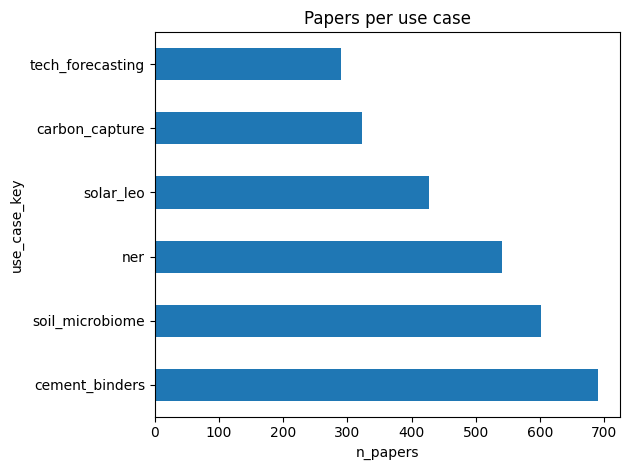

In [9]:
df["use_case_key"].value_counts().plot(kind="barh", title="Papers per use case")
plt.xlabel("n_papers")
plt.tight_layout()
plt.show()

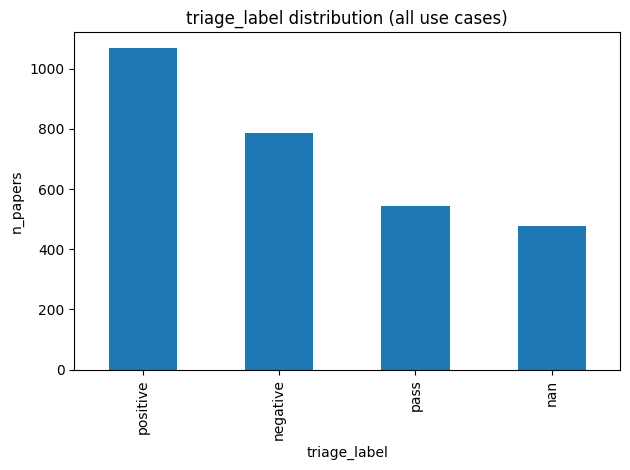

In [10]:
df["triage_label"].value_counts(dropna=False).plot(kind="bar", title="triage_label distribution (all use cases)")
plt.ylabel("n_papers")
plt.tight_layout()
plt.show()

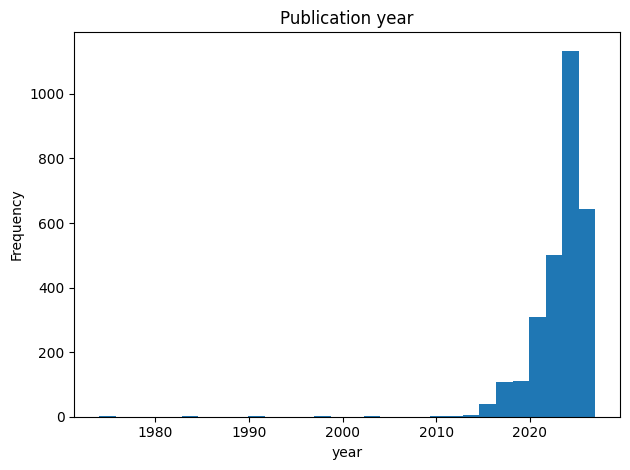

In [11]:
df["year"].plot(kind="hist", bins=30, title="Publication year")
plt.xlabel("year")
plt.tight_layout()
plt.show()

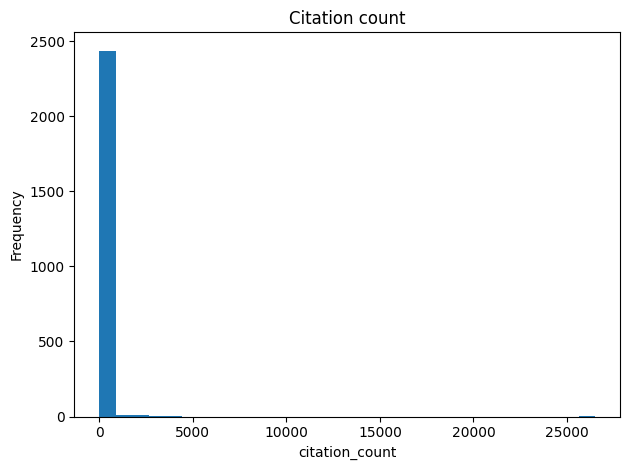

In [12]:
df["citation_count"].plot(kind="hist", bins=30, title="Citation count")
plt.xlabel("citation_count")
plt.tight_layout()
plt.show()

## 6. A peek at the broadcast use-case fields

Every row also carries its use case's search brief — here's what that looks like for
one paper per use case.

In [13]:
df.groupby("use_case_key", observed=True).first()[["use_case_name", "objective", "trl_min", "trl_max"]]

,use_case_name,objective,trl_min,trl_max
use_case_key,,,,
carbon_capture,Carbon Capture,Find amine-based carbon capture approaches tha...,<NA>,<NA>
cement_binders,Low-carbon cement binders,Find alternative binder chemistries at TRL 4–8...,1,4
ner,Named Entity Recognition,"Improve Precision, Recall, and F1 scores for n...",6,9
soil_microbiome,High quality microbial and fungal community in...,Identify research on microbial and fungal comm...,<NA>,<NA>
solar_leo,Solar Cells for Low Earth Orbit Satellites,Scout perovskite solar cells and silicon-based...,3,9
tech_forecasting,Predicting Technology Developments,Explore methods for predicting technological b...,<NA>,<NA>


## Where to go next

- **`explore_use_cases.ipynb`** — deeper structure/volume comparison across the 6
  raw JSONL exports (schema, null rates, label balance, duplicates).
- **`explore_usecase_definitions.ipynb`** — structure of the 6 `usecase.json` search
  briefs, and how each definition compares against its resulting corpus.
- **`../data_compile/combine_use_cases.ipynb`** — exactly how `papers_combined.parquet`
  was built, and every cleaning decision made along the way.
- Root **`CLAUDE.md`** — this project's non-negotiable conventions (NULL ≠ 0,
  cross-validate honestly, label which critic is speaking) — worth reading before
  you build anything on top of this data.